<a href="https://colab.research.google.com/github/simran2007-gupta/email-spam/blob/main/EmailSpamDetectionProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score,GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, r2_score, mean_squared_error, mean_absolute_error, confusion_matrix
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import joblib
from scipy import stats
from scipy.stats import skew, kurtosis, pearsonr, chi2_contingency
from dateutil.relativedelta import relativedelta
from datetime import datetime
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
df = pd.read_csv('/content/processed_data.csv')
df.head()

,label,subject,email_to,email_from,message
0,1,"Generic Cialis, branded quality@",the00@speedy.uwaterloo.ca,"""Tomas Jacobs"" <RickyAmes@aol.com>",Content-Type: text/html;\nContent-Transfer-Enc...
1,0,Typo in /debian/README,debian-mirrors@lists.debian.org,Yan Morin <yan.morin@savoirfairelinux.com>,"Hi, i've just updated from the gulus and I che..."
2,1,authentic viagra,<the00@plg.uwaterloo.ca>,"""Sheila Crenshaw"" <7stocknews@tractionmarketin...","Content-Type: text/plain;\n\tcharset=""iso-8859..."
3,1,Nice talking with ya,opt4@speedy.uwaterloo.ca,"""Stormy Dempsey"" <vqucsmdfgvsg@ruraltek.com>","Hey Billy, \n\nit was really fun going out the..."
4,1,or trembling; stomach cramps; trouble in sleep...,ktwarwic@speedy.uwaterloo.ca,"""Christi T. Jernigan"" <dcube@totalink.net>",Content-Type: multipart/alternative;\n ...


In [ ]:
df.shape

(75419, 5)

In [ ]:
df.isnull().sum()

,0
label,0
subject,793
email_to,576
email_from,0
message,1487


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75419 entries, 0 to 75418
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   label       75419 non-null  int64 
 1   subject     74626 non-null  object
 2   email_to    74843 non-null  object
 3   email_from  75419 non-null  object
 4   message     73932 non-null  object
dtypes: int64(1), object(4)
memory usage: 2.9+ MB


In [ ]:
df.duplicated().sum()

np.int64(1512)

<Axes: xlabel='label'>

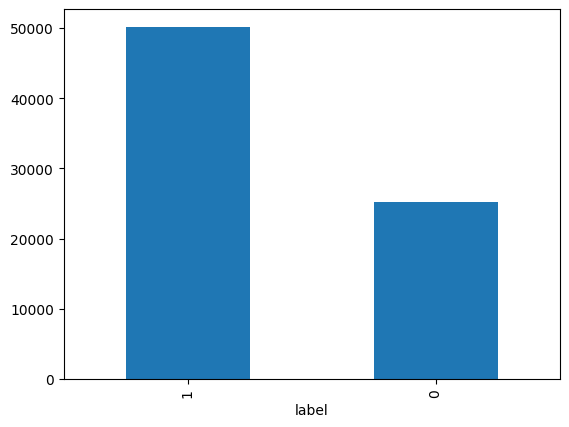

In [ ]:
df['label'].value_counts().plot(kind='bar')

In [ ]:
# label: This is the label for the email, if it is 1 then spam else ham
# subject: Subject of the email
# email_to: Receiver of the email
# email_from: Sender of the email
# message: Email body

In [ ]:
df = df.dropna(subset=['message'])

In [ ]:
df['email_to'] = df['email_to'].fillna('unknown')

In [ ]:
df['subject'] = df['subject'].fillna('missing text')

In [ ]:
df.isnull().sum()

,0
label,0
subject,0
email_to,0
email_from,0
message,0


In [ ]:
df = df.drop_duplicates(keep= 'first')

In [ ]:
df['label'].value_counts()

,count
label,
1,47767
0,24701


In [ ]:
df['message_length'] = df['message'].str.len()
df['subject_length'] = df['subject'].str.len()

In [ ]:
df.head()

,label,subject,email_to,email_from,message,message_length,subject_length
0,1,"Generic Cialis, branded quality@",the00@speedy.uwaterloo.ca,"""Tomas Jacobs"" <RickyAmes@aol.com>",Content-Type: text/html;\nContent-Transfer-Enc...,225,33
1,0,Typo in /debian/README,debian-mirrors@lists.debian.org,Yan Morin <yan.morin@savoirfairelinux.com>,"Hi, i've just updated from the gulus and I che...",728,22
2,1,authentic viagra,<the00@plg.uwaterloo.ca>,"""Sheila Crenshaw"" <7stocknews@tractionmarketin...","Content-Type: text/plain;\n\tcharset=""iso-8859...",410,16
3,1,Nice talking with ya,opt4@speedy.uwaterloo.ca,"""Stormy Dempsey"" <vqucsmdfgvsg@ruraltek.com>","Hey Billy, \n\nit was really fun going out the...",649,20
4,1,or trembling; stomach cramps; trouble in sleep...,ktwarwic@speedy.uwaterloo.ca,"""Christi T. Jernigan"" <dcube@totalink.net>",Content-Type: multipart/alternative;\n ...,17480,65


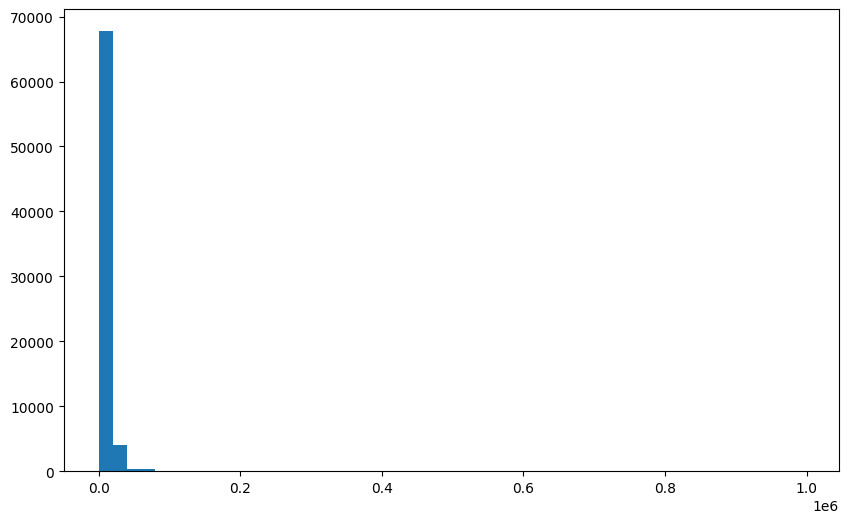

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['message_length'], bins=50)
plt.show()

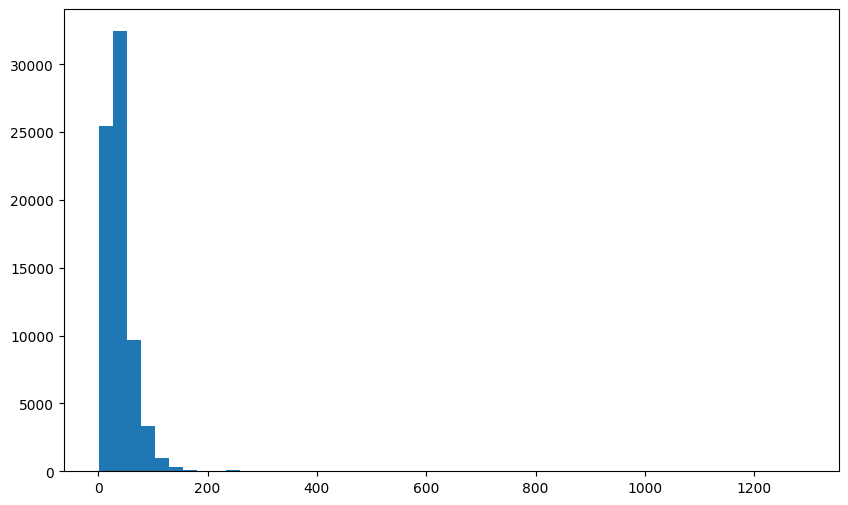

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['subject_length'], bins=50)
plt.show()

In [ ]:
df['text_all'] = (
    df['subject'].fillna('') + ' ' +
    df['email_from'].fillna('') + ' ' +
    df['message'].fillna('')
)

In [ ]:
df.head()

,label,subject,email_to,email_from,message,message_length,subject_length,text_all
0,1,"Generic Cialis, branded quality@",the00@speedy.uwaterloo.ca,"""Tomas Jacobs"" <RickyAmes@aol.com>",Content-Type: text/html;\nContent-Transfer-Enc...,225,33,"Generic Cialis, branded quality@ ""Tomas Jacob..."
1,0,Typo in /debian/README,debian-mirrors@lists.debian.org,Yan Morin <yan.morin@savoirfairelinux.com>,"Hi, i've just updated from the gulus and I che...",728,22,Typo in /debian/README Yan Morin <yan.morin@sa...
2,1,authentic viagra,<the00@plg.uwaterloo.ca>,"""Sheila Crenshaw"" <7stocknews@tractionmarketin...","Content-Type: text/plain;\n\tcharset=""iso-8859...",410,16,"authentic viagra ""Sheila Crenshaw"" <7stocknews..."
3,1,Nice talking with ya,opt4@speedy.uwaterloo.ca,"""Stormy Dempsey"" <vqucsmdfgvsg@ruraltek.com>","Hey Billy, \n\nit was really fun going out the...",649,20,"Nice talking with ya ""Stormy Dempsey"" <vqucsmd..."
4,1,or trembling; stomach cramps; trouble in sleep...,ktwarwic@speedy.uwaterloo.ca,"""Christi T. Jernigan"" <dcube@totalink.net>",Content-Type: multipart/alternative;\n ...,17480,65,or trembling; stomach cramps; trouble in sleep...


In [ ]:
df.columns

Index(['label', 'subject', 'email_to', 'email_from', 'message',
       'message_length', 'subject_length', 'text_all'],
      dtype='object')

In [ ]:
df = df[['label','message_length', 'subject_length', 'text_all']]
df.head()

,label,message_length,subject_length,text_all
0,1,225,33,"Generic Cialis, branded quality@ ""Tomas Jacob..."
1,0,728,22,Typo in /debian/README Yan Morin <yan.morin@sa...
2,1,410,16,"authentic viagra ""Sheila Crenshaw"" <7stocknews..."
3,1,649,20,"Nice talking with ya ""Stormy Dempsey"" <vqucsmd..."
4,1,17480,65,or trembling; stomach cramps; trouble in sleep...


In [ ]:
from nltk.stem import WordNetLemmatizer
import re
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
df['text_all'] = df['text_all'].apply(lambda x : x.lower())

In [ ]:
import string

def remove_punc(txt):
  return txt.translate(str.maketrans('','',string.punctuation))

In [ ]:
df['text_all'] = df['text_all'].apply(remove_punc)

In [ ]:
def replace_numbers(text):
    return re.sub(r'\d+', ' NUM ', text)

df['text_all'] = df['text_all'].apply(replace_numbers)

In [ ]:
def remove_emojis(txt):
    new = ""
    for i in txt:
        if i.isascii():
            new += i
    return new

df['text_all'] = df['text_all'].apply(remove_emojis)

In [ ]:
def replace_urls(text):
    text = str(text)
    return re.sub(r'https?://\S+|www\.\S+', ' URL ', text)

df['text_all'] = df['text_all'].apply(replace_urls)

In [ ]:
def remove_html(text):
    text = str(text)
    return re.sub(r'<.*?>', '', text)

df['text_all'] = df['text_all'].apply(remove_html)

In [ ]:
def replace_email_addresses(text):
    text = str(text)
    return re.sub(
        r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b',
        ' EMAIL ',
        text
    )

df['text_all'] = df['text_all'].apply(replace_email_addresses)

In [ ]:
def remove_extra_whitespace(text):
    text = str(text)
    return re.sub(r'\s+', ' ', text).strip()

df['text_all'] = df['text_all'].apply(remove_extra_whitespace)

In [ ]:
def lemmatize_text(text):
    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    return " ".join(words)
df['text_all'] = df['text_all'].apply(lemmatize_text)

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
df.shape

(72468, 4)

In [ ]:
df.columns

Index(['label', 'message_length', 'subject_length', 'text_all'], dtype='object')

In [ ]:
x_text = df['text_all']
x_numeric = df[['message_length','subject_length']]
y = df['label']

In [ ]:
x_train_text, x_test_text, x_train_num, x_test_num, y_train, y_test = train_test_split(x_text,x_numeric,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
tfidf = TfidfVectorizer(max_features=10000,ngram_range=(1,2),min_df=2)
x_train_text = tfidf.fit_transform(x_train_text)
x_test_text = tfidf.transform(x_test_text)

In [ ]:
scaler = StandardScaler()
x_train_num = scaler.fit_transform(x_train_num)
x_test_num = scaler.transform(x_test_num)

In [ ]:
from scipy.sparse import hstack
x_train = hstack((x_train_text, x_train_num))
x_test = hstack((x_test_text, x_test_num))

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      4940
           1       0.98      1.00      0.99      9554

    accuracy                           0.99     14494
   macro avg       0.99      0.98      0.98     14494
weighted avg       0.99      0.99      0.99     14494

[[4772  168]
 [  43 9511]]


In [ ]:
from sklearn.svm import LinearSVC
model = LinearSVC()
model.fit(x_train, y_train)

LinearSVC()

In [ ]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      4940
           1       0.98      1.00      0.99      9554

    accuracy                           0.99     14494
   macro avg       0.99      0.98      0.98     14494
weighted avg       0.99      0.99      0.99     14494

[[4772  168]
 [  43 9511]]


In [ ]:
from sklearn.metrics import  recall_score, precision_score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(precision)
print(recall)
print(f1)

0.982642835003616
0.9954992673225874
0.9890292726043779


In [ ]:
joblib.dump(model, "spam_classifier.pkl")
joblib.dump(tfidf, "tfidf_vectorizer_spam.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']